In [1]:
!pip install numpy

In [3]:
!pip install pandas

In [5]:
!pip install matplotlib

In [7]:
!pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
# 1. Load the dataset
df = pd.read_csv('CC General.csv')

In [7]:
# 2. Dimensions of the dataset
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (8950, 18)


In [9]:
# 3. View the first five rows
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [11]:
# 4. Checking data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [13]:
# 5. Count exact missing values per column
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [15]:
# 6. Fill the 1 missing value in CREDIT_LIMIT with its median 
credit_limit_median = df['CREDIT_LIMIT'].median()
df['CREDIT_LIMIT'].fillna(credit_limit_median, inplace = True)

In [17]:
# 7. Fill the 313 missing values in MINIMUM_PAYMENTS with their median
min_payment_median = df['MINIMUM_PAYMENTS'].median()
df['MINIMUM_PAYMENTS'].fillna(min_payment_median, inplace = True)

In [19]:
# 8. Double check that missing values are now ZERO
print("Missing values after cleaning:")
print(df[['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].isnull().sum())

Missing values after cleaning:
CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64


# Requirement 1: Customer Spend Segmentation

In [21]:
# 1. Define the criteria for our segments based on the data distributions
# We will use median values as a threshold to separate 'High' from 'Low'
bal_median = df['BALANCE'].median()
purch_median = df ['PURCHASES'].median()

# 2. Set up the logic rules(Conditions)
conditions = [
    (df['BALANCE'] > bal_median) & (df['PURCHASES'] <= purch_median), # High Balance, Low Spend
    (df['BALANCE'] > bal_median) & (df['PURCHASES'] > purch_median), # High Balance, High Spend
    (df['BALANCE'] <= bal_median) & (df['PURCHASES'] > purch_median), # Low Balance, High Spend
    (df['BALANCE'] <= bal_median) & (df['PURCHASES'] <= purch_median), # Low Balance, Low Spend
     ]

# 3. Define the segment names mapping to each condition above
segment_labels = [
     'Risk/Inactive',
     'VIP Spenders',
     'Active Budgeters',
     'Low Value Users',
     ]

# 4. Use NumPy to combine these conditions and create the new column
df['CUSTOMER_SEGMENT'] = np.select(conditions, segment_labels, default = 'Other')

# 5. Create a Summary Table for the Bank Executive Board
summary_table = df.groupby('CUSTOMER_SEGMENT').agg(
    customer_count = ('CUST_ID', 'count'),
    avg_credit_limit = ('CREDIT_LIMIT', 'mean'),
    avg_purchases = ('PURCHASES', 'mean'),
    total_purchases = ('PURCHASES', 'sum')
).reset_index()

# Display the summary table 
print("Executive Summary Table: Customer Segments")
summary_table

Executive Summary Table: Customer Segments


,CUSTOMER_SEGMENT,customer_count,avg_credit_limit,avg_purchases,total_purchases
0,Active Budgeters,2377,4474.171267,1455.335713,3459332.99
1,Low Value Users,2098,2959.733079,125.043275,262340.79
2,Risk/Inactive,2377,4447.106105,66.649175,158425.09
3,VIP Spenders,2098,6105.067597,2430.211816,5098584.39


In [ ]:
'''
1. Highest Customer Count: We actually have a tie in volume. Both Active Budgeters and Risky/Inactive accounts hold the highest volume, with 2,377 customers each.
2. Most Revenue (Total Purchases): The VIP Spenders contribute an overwhelming majority of the value. Despite having fewer customers (2,098), they drive over $5.09 million in total purchases, with an impressive average spend of $2,430 per customer.

Key Insights:
VIP Spenders make up the largest chunk of total purchases.
We need a targeted marketing campaign for the Risk/Inactive group.
'''

In [ ]:
'''
The Strategic Business Takeaway:
The Opportunity: Active Budgeters have a relatively lower credit limit ($4,474) but are highly active spenders ($1,455 average). We should recommend that the bank offer selective credit limit increases to this segment to capture more transaction volume.
The Risk: Risky/Inactive users hold a massive amount of the bank's credit capacity (average limit of $4,447) but are barely using it ($66 average spend). This represents locked-up capital that isn't generating swipe fees.
'''

# Requirement 2 – Purchase Behavior Visualization

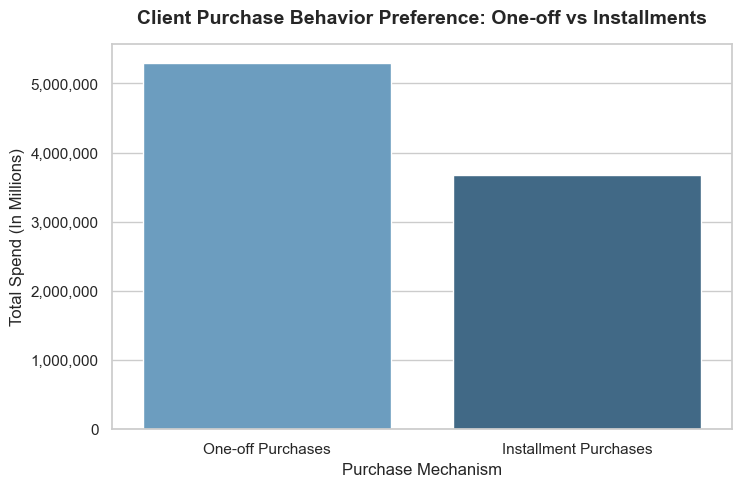

One-off to Installment Ratio: 1.44


In [23]:
# 1. Calculate the total sum of One-off vs Installment purchases
total_oneoff = df['ONEOFF_PURCHASES'].sum()
total_installments = df['INSTALLMENTS_PURCHASES'].sum()

# 2. Prepare the data for plotting
purchase_types = ['One-off Purchases', 'Installment Purchases']
total_amounts = [total_oneoff, total_installments]

# 3. Create the plot using Seaborn 
plt.figure(figsize=(8, 5))
sns.set_theme(style = "whitegrid")

# Create a bar plot 
ax = sns.barplot(x=purchase_types, y=total_amounts, palette = "Blues_d")

# Formatting the chart for the client presentation
plt.title('Client Purchase Behavior Preference: One-off vs Installments', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Spend (In Millions)', fontsize=12)
plt.xlabel('Purchase Mechanism', fontsize=12)

#Format y-axis to show numbers cleanly instead of scientific notation
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

#Show the chart
plt.show()

# 4. Calculate the percentage ratio for the final presentation
ratio = total_oneoff / total_installments
print(f"One-off to Installment Ratio: {ratio:.2f}")

In [ ]:
'''
A ratio of 1.44 means that for every $1.00 our client's customers spend on monthly installment plans (EMIs), they spend $1.44 on direct, one-off purchases.

Insights:
One-off purchases dominate the portfolio. However, installment purchases represent stable, interest-bearing revenue for the bank if users carry balances. This suggests our client has an opportunity to introduce pre-approved EMI conversion offers for large one-off transactions to maximize interest yields.
'''

# Requirement 3 – Credit Limit vs. Cash Advance Risk

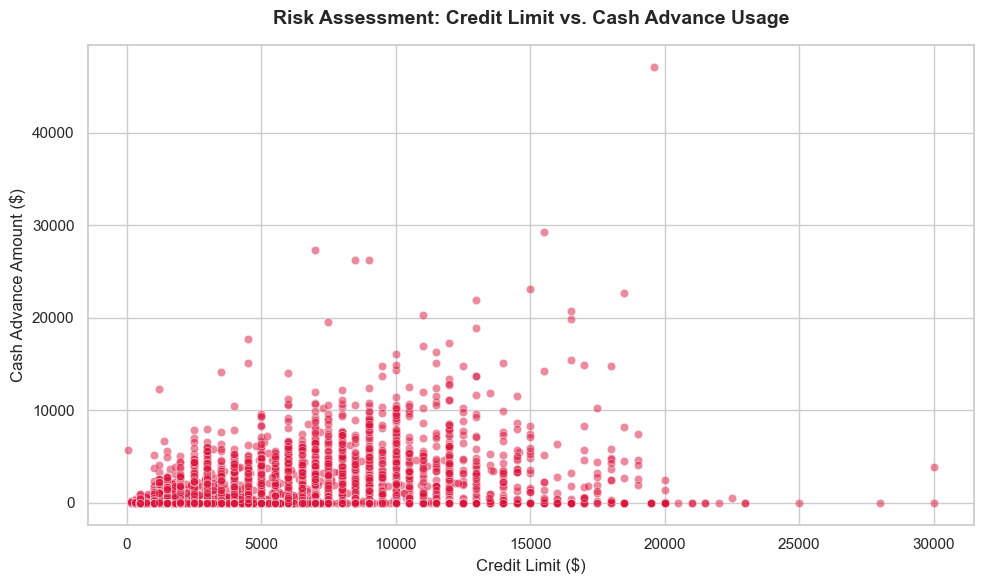

Statistical Correlation Coefficient:  0.3040


In [28]:
plt.figure(figsize=(10, 6))

# Create a scatter plot to check correlation
sns.scatterplot(
    data = df,
    x = 'CREDIT_LIMIT',
    y = 'CASH_ADVANCE',
    alpha = 0.5,       # Makes points semi-transparent to see density
    color = 'crimson'  # Red color highlights risk analysis
)

# Formatting the visualization
plt.title('Risk Assessment: Credit Limit vs. Cash Advance Usage', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Credit Limit ($)', fontsize = 12)
plt.ylabel('Cash Advance Amount ($)', fontsize = 12)

# Display the chart
plt.tight_layout()
plt.show()

# Calculate the actual statistical correlation coefficient
correlation = df['CREDIT_LIMIT'].corr(df['CASH_ADVANCE'])
print(f"Statistical Correlation Coefficient: {correlation: .4f}")

In [ ]:
'''
Correlation Coefficient (0.3040): weak-to-moderate positive correlation
As a customer's CREDIT_LIMIT goes up, their CASH_ADVANCE amount tends to go up slightly too.

Scatter Plot Spikes: This tells us the bank’s original suspicion was actually wrong. 
The highest risk of massive cash withdrawals isn't coming from the lowest-income users on the left; it's coming from users who have been granted higher credit limits ($5,000 to $15,000).
'''